# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [2]:
image = plt.imread('data/ejer_kmeans.png')
image.shape

(764, 1499, 3)

Muestra la imagen para ver que se ha cargado bien

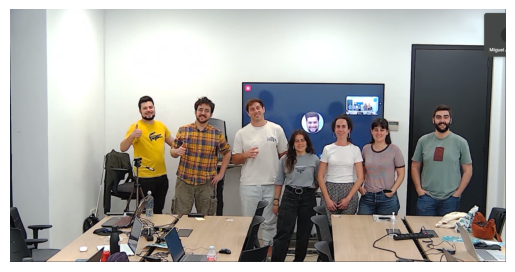

In [9]:
plt.imshow(image)
plt.axis('off'); # Sin bordes

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [15]:
# Convertir de (alto, ancho, 3) a (alto*ancho, 3)
X = image.reshape(-1, 3)
print(X.shape)

(1145236, 3)


#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [ ]:
k = 20 # 20 colores
kmeans = KMeans(n_clusters=k, n_init=10, random_state=10).fit(X)

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [22]:
centers = kmeans.cluster_centers_
labels = kmeans.labels_

print(centers)
print(labels)

[[0.20494944 0.20877665 0.22191504]
 [0.845382   0.858506   0.83717895]
 [0.67572194 0.49720842 0.41181618]
 [0.27932593 0.28558457 0.2961198 ]
 [0.9846673  0.9956032  0.983881  ]
 [0.67805517 0.6906306  0.6904258 ]
 [0.06670487 0.05798054 0.06254035]
 [0.41869575 0.23327738 0.15950945]
 [0.2780036  0.38129976 0.5258908 ]
 [0.8128855  0.7235166  0.63730854]
 [0.7502869  0.6529679  0.55956   ]
 [0.57464653 0.3852393  0.27878484]
 [0.8074497  0.62539685 0.0707258 ]
 [0.59295017 0.58098245 0.57681936]
 [0.9152614  0.94062436 0.91745317]
 [0.48727813 0.49133456 0.48444194]
 [0.13078567 0.12779838 0.13927436]
 [0.7590927  0.7730035  0.76506734]
 [0.16417113 0.25924668 0.4290919 ]
 [0.39534175 0.37995946 0.37392175]]
[13 13 13 ... 16 16 16]


#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [25]:
# Sustituir cada pixel por su centroide
segmented_pixels = centers[labels]

# Volver a la forma original
segmented_image = segmented_pixels.reshape(image.shape)

#### 7. Muestra y guarda en tu ordenador la imagen resultante

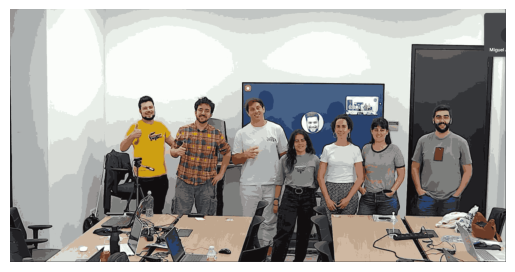

In [27]:
img7 = plt.figure()
plt.imshow(segmented_image)
plt.axis('off');

In [28]:
img7.savefig("data/Kmeans_ejer2_7.png")

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [34]:
def imagen_colores(img, num_color, action, nombre= ''):
    imagen = plt.imread('data/ejer_kmeans.png')
    X = imagen.reshape(-1, 3)
    
    kmeans = KMeans(n_clusters=num_color, n_init=10, random_state=10).fit(X)
    # centers = kmeans.cluster_centers_
    # labels = kmeans.labels_
    
    # segmented_pixels = centers[labels]
    imagen_final = kmeans.cluster_centers_[kmeans.labels_].reshape(imagen.shape)
    pic = plt.figure()
    plt.imshow(imagen_final)
    plt.axis('off');
    
    if action == 'save':
        pic.savefig(f'data/{nombre}.png')

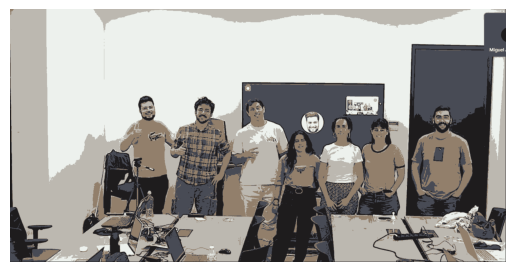

In [ ]:
# Ejemplo guardado
imagen_colores('data/ejer_kmeans.png', 5, 'save', nombre= 'img_ejer2_8')

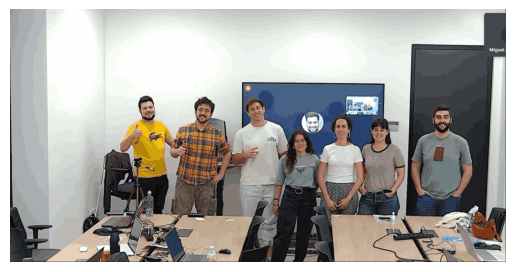

In [ ]:
# Ejemplo sin guardado
imagen_colores('data/ejer_kmeans.png', 60, 'print')